# 🧬 Breast Cancer Subtype Classification using Machine Learning

## Bioinformatics Analysis of Gene Expression Data for Breast Cancer Subtype Classification (GSE45827)

### Project Overview

Breast cancer consists of several molecular subtypes with distinct gene expression patterns. Understanding these patterns can help researchers study how breast cancer differs at the molecular level.

In this project, I explored the GSE45827 gene expression dataset from the Gene Expression Omnibus (GEO) database. I used Python to organize and analyze the expression data and then trained a machine learning model to classify samples into their recorded breast cancer subtypes.

The main purpose of this project was to learn how biological datasets can be handled computationally and to explore how machine learning can be applied to transcriptomic data.

### Objectives

- Load and preprocess a public breast cancer gene expression dataset.
- Extract molecular subtype labels.
- Train a machine learning classifier.
- Evaluate classification performance.
- Examine which features contribute to the model's classification.

---

**Dataset:** GSE45827 (NCBI GEO)

**Platform:** Affymetrix Human Genome U133 Plus 2.0 Array

**Programming Language:** Python

**Libraries:** Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn

# 1. Import Required Libraries

The libraries below are used for data handling, visualization, machine learning, and evaluation of the classification model.

In [87]:
# Data manipulation
import pandas as pd
import numpy as np

# Reading compressed GEO files
import gzip
from io import StringIO

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


# 2. Load the Dataset

The dataset is downloaded from the NCBI Gene Expression Omnibus (GEO). It contains gene expression values for 155 breast tissue samples representing different molecular subtypes.

In [88]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [89]:
file_path = "/content/drive/MyDrive/GSE45827_series_matrix.txt.gz"

In [90]:
with gzip.open(file_path, "rt") as f:
    lines = f.readlines()

print("✅ File loaded successfully.")
print("Total lines:", len(lines))

✅ File loaded successfully.
Total lines: 29943


In [91]:
import gzip
import re
import numpy as np
import pandas as pd

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [92]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'sample_data']


In [93]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
print(os.listdir("/content/drive/MyDrive/application for spring"))

['SOP', 'LOR', 'transcripts', 'MOI', 'biotechnology project', 'certificates', 'resume', 'imp points', 'breast cancer']


In [95]:
file_path = "/content/drive/MyDrive/application for spring/GSE45827_series_matrix.txt.gz"

In [96]:
labels = []

for line in lines:
    if line.startswith("!Sample_title"):

        titles = line.strip().split("\t")[1:]

        for title in titles:

            title = title.replace('"', "")

            if "Basal" in title:
                labels.append("Basal")

            elif "Her2" in title:
                labels.append("HER2")

            elif "Luminal A" in title:
                labels.append("Luminal_A")

            elif "Luminal B" in title:
                labels.append("Luminal_B")

            elif "Normal" in title:
                labels.append("Normal")

            elif "CellLine" in title:
                labels.append("CellLine")

In [97]:
from collections import Counter

print("Number of labels:", len(labels))
print(Counter(labels))

Number of labels: 155
Counter({'Basal': 41, 'HER2': 30, 'Luminal_B': 30, 'Luminal_A': 29, 'CellLine': 14, 'Normal': 11})


In [98]:
from io import StringIO
import pandas as pd

start = None
end = None

for i, line in enumerate(lines):

    if "!series_matrix_table_begin" in line:
        start = i + 1

    if "!series_matrix_table_end" in line:
        end = i
        break

matrix_text = "".join(lines[start:end])

df = pd.read_csv(
    StringIO(matrix_text),
    sep="\t"
)

print("Expression matrix loaded successfully.")
print(df.shape)

Expression matrix loaded successfully.
(29873, 156)


In [99]:
df = df.set_index("ID_REF")

print(df.shape)

df.head()

(29873, 155)


,GSM1116084,GSM1116085,GSM1116086,GSM1116087,GSM1116088,GSM1116089,GSM1116090,GSM1116091,GSM1116092,GSM1116093,...,GSM1116229,GSM1116230,GSM1116231,GSM1116232,GSM1116233,GSM1116234,GSM1116235,GSM1116236,GSM1116237,GSM1116238
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,9.47065,9.67440,10.20800,10.11420,11.16360,10.00690,9.53932,9.00187,6.54074,10.35510,...,9.96811,10.10680,10.03290,9.84599,10.75850,10.55470,9.45290,10.80010,10.04640,11.42010
1053_at,8.36311,8.72194,7.78601,9.44537,7.71242,7.84274,7.56238,8.01540,9.37874,9.45426,...,7.25745,7.54377,7.41607,5.83454,8.83376,6.88277,6.83700,7.29371,7.71122,7.63877
117_at,5.95426,7.02523,6.39671,4.56023,5.29008,6.21590,6.42180,6.23554,5.43541,3.85652,...,8.35832,6.98743,4.50611,4.78051,4.55847,4.14597,6.10766,5.41169,4.57742,4.67159
1294_at,6.02119,7.24581,6.85310,5.42786,7.51120,5.79719,7.36700,7.17268,7.72472,4.79560,...,7.18591,7.74070,7.44448,7.03001,6.87039,6.37882,6.99674,8.37598,6.56774,7.40374
1316_at,3.22997,3.29352,3.26204,3.34766,3.59086,3.40108,3.27663,3.14212,3.28420,3.27900,...,3.50312,3.57309,3.31572,3.70289,4.82208,3.55309,3.23899,3.84879,3.28091,3.24882


In [100]:
X = df.T

X["Label"] = labels

print("Dataset shape:", X.shape)

X.head()

Dataset shape: (155, 29874)


ID_REF,1007_s_at,1053_at,117_at,1294_at,1316_at,1405_i_at,1438_at,1487_at,1552256_a_at,1552257_a_at,...,89476_r_at,90265_at,90610_at,91617_at,91684_g_at,91703_at,91816_f_at,91826_at,91952_at,Label
GSM1116084,9.47065,8.36311,5.95426,6.02119,3.22997,10.82220,4.39698,6.65320,10.91320,10.07510,...,7.67662,8.58529,6.58532,6.47111,8.05685,5.51480,6.04568,5.90542,4.34839,Basal
GSM1116085,9.67440,8.72194,7.02523,7.24581,3.29352,9.29455,6.68936,7.20820,9.32204,9.34476,...,7.32080,6.21915,6.81551,6.54900,6.62661,5.58320,5.67661,6.68275,4.94622,Basal
GSM1116086,10.20800,7.78601,6.39671,6.85310,3.26204,9.45727,5.46440,6.68974,7.73131,8.43573,...,7.53787,7.86806,6.90606,6.32751,7.51148,5.85887,3.14257,7.77158,3.58973,HER2
GSM1116087,10.11420,9.44537,4.56023,5.42786,3.34766,11.51270,5.29748,6.87276,10.39210,9.63893,...,7.86515,8.79839,7.09756,6.03216,7.38772,4.55774,3.04537,6.47312,4.55167,Basal
GSM1116088,11.16360,7.71242,5.29008,7.51120,3.59086,8.83075,6.81821,6.45744,7.05836,9.37463,...,7.33174,7.01692,5.51992,6.09710,6.41229,5.34572,4.33680,8.48681,4.72397,HER2


##  Split Features and Labels

In [101]:
# Features (gene expression values)
X = X.drop(columns=["Label"])

# Target (breast cancer subtype)
y = labels

print("Features shape:", X.shape)
print("Number of labels:", len(y))

Features shape: (155, 29873)
Number of labels: 155


##  Split Data into Training and Testing Sets

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 124
Testing samples: 31


##  Train Random Forest Classifier

In [103]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("✅ Random Forest model trained successfully.")

✅ Random Forest model trained successfully.


## Make Predictions

In [104]:
y_pred = rf.predict(X_test)

print("Predictions completed successfully.")

Predictions completed successfully.


##  Model Accuracy

In [105]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy*100:.2f}%")

Model Accuracy: 1.0000
Accuracy Percentage: 100.00%


In [106]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00         8
    CellLine       1.00      1.00      1.00         3
        HER2       1.00      1.00      1.00         6
   Luminal_A       1.00      1.00      1.00         6
   Luminal_B       1.00      1.00      1.00         6
      Normal       1.00      1.00      1.00         2

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



In [107]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Cross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross-validation scores: [1.         1.         1.         0.96774194 0.90322581]
Mean Accuracy: 0.9741935483870968


In [108]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[8 0 0 0 0 0]
 [0 3 0 0 0 0]
 [0 0 6 0 0 0]
 [0 0 0 6 0 0]
 [0 0 0 0 6 0]
 [0 0 0 0 0 2]]


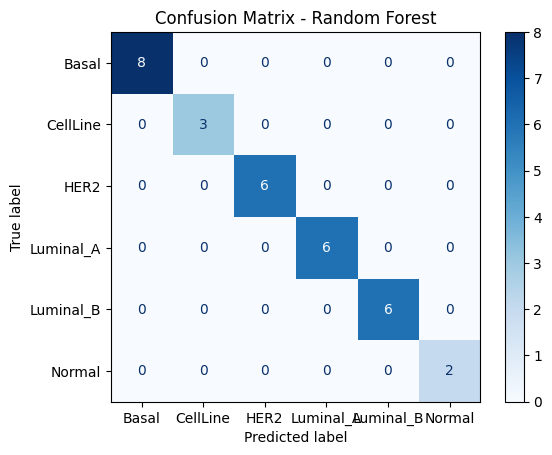

In [109]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [110]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
18534,223523_at,0.004189
14714,218195_at,0.003611
9352,209604_s_at,0.003328
11240,212496_s_at,0.003293
6816,205225_at,0.003287
25089,233388_at,0.003219
20611,226192_at,0.003183
18759,223892_s_at,0.003151
14825,218309_at,0.003132
13663,216088_s_at,0.003123


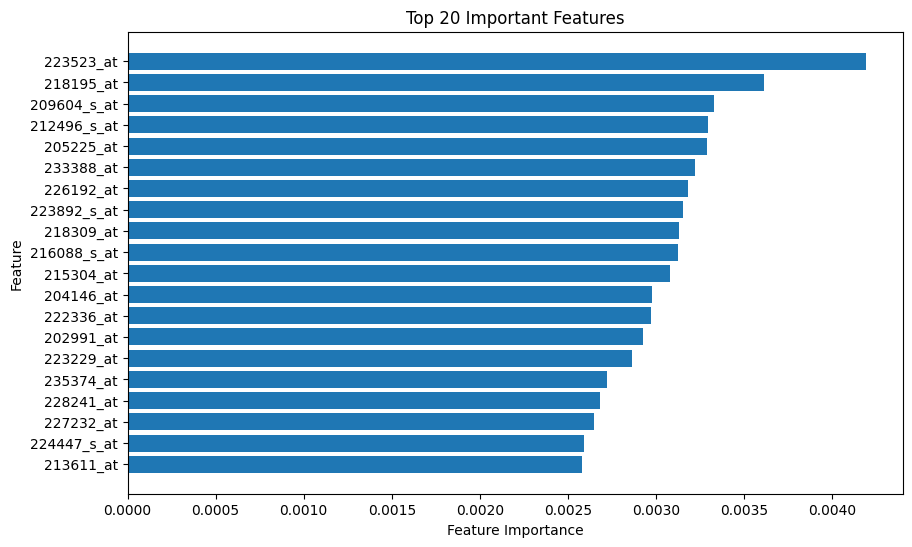

In [111]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["Feature"], top20["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features")
plt.gca().invert_yaxis()
plt.show()

## Limitations

- The dataset contains only 155 samples.
- Performance was evaluated on a single dataset.
- External validation using independent datasets was not performed.
- Feature importance indicates predictive value but does not establish biological causality.

# Conclusion

This project explored the use of machine learning for classifying breast cancer subtypes using gene expression data from the GEO dataset GSE45827.

## Summary

- Parsed and processed a public GEO gene expression dataset.
- Prepared gene expression data from 155 samples.
- Assigned six recorded sample classes.
- Built a Random Forest classifier.
- Evaluated the model using accuracy, precision, recall, and F1-score.
- Examined feature importance from the trained model.

## Results

The Random Forest classifier achieved 100% accuracy on the held-out test set used in this project. Five-fold cross-validation produced a mean accuracy of approximately 97.4%, although performance varied between folds. The classification results suggest that the gene expression profiles in this dataset contain patterns that can distinguish the recorded sample classes.

However, this result should be interpreted within the scope of the dataset and evaluation setup rather than as evidence of clinical performance.

## Limitations

- The dataset contains only 155 samples.
- The model was evaluated using a single train-test split.
- External validation using an independent dataset was not performed.
- The model is intended for educational and exploratory analysis and is not a clinical diagnostic tool.
- Feature importance reflects predictive contribution to the model and does not establish biological causality.

## Future Work

Future improvements could include testing the model on independent datasets, comparing multiple machine learning approaches, performing differential gene expression analysis, and investigating biological pathways associated with the identified features.